In [158]:
import datetime as dt
import math
import matplotlib.pyplot as plt
import meteostat
import numpy as np
import pandas as pd
import requests
import statistics
import warnings; warnings.simplefilter('ignore')
import xgboost as xgb

from category_encoders import TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [159]:
def weighted_rmse_obj(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Custom objective function for RMSE weighted by deviation from mean.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    grad (array): Gradient of the loss.
    hess (array): Hessian (second derivative) of the loss.
    """

    mean = np.mean(y_true)
    std = np.std(y_true)
    
    # Calcul des poids en fonction de l'écart par rapport à la moyenne
    weights = 1 + (np.abs(y_true - mean) / std)
    
    errors = y_pred - y_true
    grad = weights * errors
    hess = weights
    
    return grad, hess

def percentiles_weighted_rmse_obj(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Custom percentiles weighted RMSE objective function.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    grad (array): Gradient of the loss.
    hess (array): Hessian (second derivative) of the loss.
    """
    percentile_95 = np.percentile(y_true, 95)
    percentile_90 = np.percentile(y_true, 90)
    percentile_85 = np.percentile(y_true, 85)
    percentile_80 = np.percentile(y_true, 80)
    percentile_75 = np.percentile(y_true, 75)
    percentile_70 = np.percentile(y_true, 70)
    percentile_65 = np.percentile(y_true, 65)
    percentile_60 = np.percentile(y_true, 60)
    percentile_55 = np.percentile(y_true, 55)
    percentile_50 = np.percentile(y_true, 50)
    
    weights = np.ones_like(y_true)
    weights[y_true > percentile_55] = 1.5
    weights[y_true > percentile_60] = 2
    weights[y_true > percentile_65] = 2.5
    weights[y_true > percentile_70] = 3
    weights[y_true > percentile_75] = 3.5
    weights[y_true > percentile_80] = 4
    weights[y_true > percentile_85] = 4.5
    weights[y_true > percentile_90] = 5
    weights[y_true > percentile_95] = 5.5
    # weights[y_true < percentile_5] = 5   # Poids plus élevé pour les creux


    errors = y_pred - y_true
    grad = weights * errors
    hess = weights
    
    return grad, hess

def weighted_rmse(y_true, y_pred):
    """
    Custom evaluation metric for RMSE weighted by deviation from mean.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    weighted_rmse_value (float): Value of the weighted RMSE.
    """

    
    mean = np.mean(y_true)
    std = np.std(y_true)
    
    # Calcul des poids en fonction de l'écart par rapport à la moyenne
    weights = 1 + (np.abs(y_true - mean) / std)

    # print(weights)

    errors = y_pred - y_true
    weighted_squared_errors = weights * errors ** 2
    weighted_rmse_value = np.sqrt(np.mean(weighted_squared_errors))
    
    return weighted_rmse_value

def percentiles_weighted_rmse(y_true, y_pred):
    """
    Custom evaluation metric for percentiles weighted RMSE.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    weighted_rmse_value (float): Value of the weighted RMSE.
    """
    
    percentile_95 = np.percentile(y_true, 95)
    percentile_90 = np.percentile(y_true, 90)
    percentile_85 = np.percentile(y_true, 85)
    percentile_80 = np.percentile(y_true, 80)
    percentile_75 = np.percentile(y_true, 75)
    percentile_70 = np.percentile(y_true, 70)
    percentile_65 = np.percentile(y_true, 65)
    percentile_60 = np.percentile(y_true, 60)
    percentile_55 = np.percentile(y_true, 55)
    percentile_50 = np.percentile(y_true, 50)
    
    weights = np.ones_like(y_true)
    weights[y_true > percentile_55] = 1.5
    weights[y_true > percentile_60] = 2
    weights[y_true > percentile_65] = 2.5
    weights[y_true > percentile_70] = 3
    weights[y_true > percentile_75] = 3.5
    weights[y_true > percentile_80] = 4
    weights[y_true > percentile_85] = 4.5
    weights[y_true > percentile_90] = 5
    weights[y_true > percentile_95] = 5.5

    # print(weights)

    errors = y_pred - y_true
    weighted_squared_errors = weights * errors ** 2
    weighted_rmse_value = np.sqrt(np.mean(weighted_squared_errors))
    
    return weighted_rmse_value

reg = xgb.XGBRegressor()
reg.set_params(**{'objective': percentiles_weighted_rmse_obj, 
                  'early_stopping_round':15,
                  'eval_metric': percentiles_weighted_rmse})

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_round=15,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=<function percentiles_weighted_rmse at 0x135f97b50>,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [160]:
def teste(df, params):
    means, rmses = [], []
    for random_state in range(42, 45):
        train_val_set, test_set = train_test_split(df, test_size=0.2, random_state=random_state)
        train_set, val_set = train_test_split(train_val_set, test_size=0.2, random_state=random_state)
        
        X_train = train_set.drop('target', axis=1)
        y_train = train_set['target']
        X_val = val_set.drop('target', axis=1)
        y_val = val_set['target']
        X_test = test_set.drop('target', axis=1)
        y_test = test_set['target']
        '''        
        reg = xgb.XGBRegressor(**params,
                               n_estimators=100000,
                               random_state=random_state,
                               n_jobs=-1,
                               early_stopping_rounds=10)
        '''
        reg.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False)
        means.append(mean_absolute_error(reg.predict(X_test), y_test))
        rmses.append(math.sqrt(mean_squared_error(reg.predict(X_test), y_test)))
    #return (statistics.mean(means), statistics.mean(rmses)) 
    return (min(means), min(rmses)) 

In [161]:
%pylab inline
pylab.rcParams['figure.figsize'] = (18, 8)

global_year = {'predict': [], 'actual': []}

def teste_final(df, params, start, stop, plot=True):
    global global_year
    test_set:pd.DataFrame = df.loc[(df.index>=start)&(df.index<=stop)]
    train_val_set:pd.DataFrame = df.loc[(df.index<start)|(df.index>stop)]
    train_val_set:pd.DataFrame = df.loc[df.index<start]
    #print(f"train_val_set : {train_val_set}")
    ls = train_test_split(train_val_set, test_size=0.2)
    train_set:pd.DataFrame = ls[0]
    val_set:pd.DataFrame = ls[1]
    X_train:pd.DataFrame = train_set.drop('target', axis=1)
    #print(f"X_train : {X_train}")
    y_train:pd.DataFrame = train_set['target'].to_frame()
    #print(f"y_train : {y_train}")
    X_val:pd.DataFrame = val_set.drop('target', axis=1)
    y_val:pd.DataFrame = val_set['target'].to_frame()
    X_test:pd.DataFrame = test_set.drop('target', axis=1)
    y_test:pd.DataFrame = test_set['target'] #.to_frame()
    '''
    reg = xgb.XGBRegressor(**params,
                           n_estimators=100000,
                           n_jobs=-1,
                           early_stopping_rounds=15)
    '''
    #print number of features to check if it is the same as the number of columns in X_train
    # print(f"Number of features : {len(X_train.columns)}")
    # print(f"Number of features : {len(y_train.columns)}")
    # print(f"Number of features : {len(X_val.columns)}")
    # print(f"Number of features : {len(y_val.columns)}")
    reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)
    y_pred = reg.predict(X_test)
    global_year['predict'].extend(list(y_pred))
    global_year['actual'].extend(list(y_test))
    # print("y_test : ", y_test)
    # print("y_pred : ", y_pred)
    if plot:
        plt.figure()
        plt.plot(X_test.index, y_pred, label='predicted')
        plt.plot(X_test.index, y_test, label='actual')
        plt.legend()
        plt.title(f"MAE : {mean_absolute_error(reg.predict(X_test), y_test)}")
        plt.show()
        if start.month==11:
            xgb.plot_importance(reg)
            fig = matplotlib.pyplot.gcf()
            fig.set_size_inches(10, 10)
            fig.show()
    print(f" MAE finale : {mean_absolute_error(reg.predict(X_test), y_test)}")
    return [(X_test.index, y_pred), (X_test.index, y_test), reg]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [162]:
def select_features(df0, target='target', num_feats=100):
    df = df0.copy()
    nan_columns = [(k, df[k].isna().sum()) for k in df if df[k].isna().sum()>0]
    if len(nan_columns) > 0:
        # enregistre_exception(f'Il y a des colonnes avec des nan : {nan_columns}', to_file=False)
        print(f"Taille de df avant suppression des colonnes de NaN: {df.shape}")
        df = df.dropna(axis=1)
        print(f"Taille de df après suppression des colonnes de NaN: {df.shape}")
    # On enlève les colonnes de target
    if df.shape[1]-1 < num_feats:
        # enregistre_exception(f"Pas assez de features ({df.shape[1]} pour {num_feats} à sélectionner)", to_file=False)
        num_feats = df.shape[1]-1
    print("=> Recherche des features pertinentes")
    '''
    print("   - Grande variance")
    variances = df.var()
    high_variance = list(variances[variances > 0.5].index)
    if target in high_variance:
        high_variance.remove(target)
    '''
    print("   - Coefficient de corrélation de Pearson")
    correlations = sorted([(k, abs(df[k].corr(df[target]))) for k in df.columns if k not in [target]], key=lambda x:x[1], reverse=True)
    #correlations = sorted([(k, abs(np.corrcoef(df[k], df[target])[0,1])) for k in df.columns if k not in [target]], key=lambda x:x[1], reverse=True)
    Liste_Pearson = [u[0] for u in correlations if u[1] >= 0.4]
    print("   - Coefficient de corrélation de Kendall")
    method = 'kendall'
    correlations = sorted([(k, abs(df[[k, target]].corr(method=method).values[0,1])) for k in df.columns 
                                if k not in [target, 'date']], key=lambda x:x[1], reverse=True)
    Liste_Kendall = [u[0] for u in correlations if u[1] >= 0.4]
    print("   - Coefficient de corrélation de Spearman")
    method = 'spearman'
    correlations = sorted([(k, abs(df[[k, target]].corr(method=method).values[0,1])) for k in df.columns 
                                if k not in [target, 'date']], key=lambda x:x[1], reverse=True)
    Liste_Spearman = [u[0] for u in correlations if u[1] >= 0.4]
    X = df.drop(target, axis=1)
    y = df[target]
    print("   - Random forests")
    dico = dict(n_estimators=100, max_depth=7)
    dico.update(n_jobs=-1)
    embeded_rf_selector = SelectFromModel(
                    RandomForestRegressor(**dico),
                    max_features=num_feats)
    embeded_rf_selector.fit(X, y)
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = X.loc[:, embeded_rf_support].columns.tolist()
    print("   - Régression linéaire")    
    embeded_lr_selector = SelectFromModel(LinearRegression(),max_features=num_feats)
    embeded_lr_selector.fit(X, y)
    embeded_lr_support = embeded_lr_selector.get_support()
    true_indices = embeded_lr_support.nonzero()[0].tolist()
    embeded_lr_feature = [X.columns[i] for i in true_indices]
    print("   - Chi-2 selector")
    X = df.drop(target, axis=1)
    y = df[target]
    X_norm = MinMaxScaler().fit_transform(X)
    chi_selector = SelectKBest(chi2, k=num_feats)
    chi_selector.fit(X_norm, y)
    chi_support = chi_selector.get_support()
    chi_feature = X.loc[:, chi_support].columns.tolist()
    print("   - Extra trees")
    model = ExtraTreesRegressor(n_jobs=-1, max_depth=7)
    model.fit(X,y)
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    xt_features = list(feat_importances.nlargest(num_feats).index)
    print("   - XGBoost")
    train_set, val_set = train_test_split(df, test_size=0.2)
    X_train = train_set.drop(target, axis=1)
    X_val = val_set.drop(target, axis=1)
    y_train = train_set[target]
    y_val = val_set[target]
    dico_xgb = {'max_depth': 7, 'early_stopping_rounds':6, 'n_estimators': 100000}
    reg = xgb.XGBRegressor(**dico_xgb)
    reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)
    a, b = X_train.columns, reg.feature_importances_
    res_xgb = sorted([(a[k], b[k]) for k in range(len(X.columns))], key=lambda x:x[1], reverse=True)
    features_xgb = [k[0] for k in res_xgb[:num_feats]]
    print("   - Lasso")
    rfe_selector = RFE(estimator=Lasso(alpha=0.1),
                    n_features_to_select=num_feats,
                    step=100, verbose=5)
    rfe_selector.fit(X, y)
    rfe_support = rfe_selector.get_support()
    rfe_feature = X.loc[:,rfe_support].columns.tolist()
    total = Liste_Pearson+Liste_Kendall+Liste_Spearman+embeded_lr_feature+embeded_rf_feature+chi_feature+xt_features+features_xgb+rfe_feature
    total = sorted(set([(k, total.count(k)) for k in total if total.count(k)>1]), key=lambda x:x[1], reverse=True)[:num_feats]
    print(f"Classement final: {total}")
    '''
    final = [k for k in total if k[0]=='en_cours']
    final.extend([k for k in total if 'en_cours_' in k[0]])
    final.extend([k for k in total if k[0] in [f'interv-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in [f'appels-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in [f'appels_somme-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in ['hour', 'dayofweek', 'dayofyear']])
    final.extend([k for k in total if 'interv-' not in k[0] 
        and 'appels-' not in k[0] and k[0] not in [u[0] for u in final]])
    final.extend([k for k in total if k[0] not in [u[0] for u in final]])
    '''
    autoregressif = [k for k in total if 'interventions' in k[0] or 'en_cours' in k[0]]
    tendances = [k for k in total if 'moving_average' in k[0]]
    hexogenes = [k for k in total if k not in autoregressif and k not in tendances]
    final = []
    '''
    for k in range(max([len(autoregressif), len(tendances), len(hexogenes)])):
        if k <= len(tendances)-1:
            final.append(tendances[k][0])
        if k <= len(hexogenes)-1:
            final.append(hexogenes[k][0])    
        if k <= len(autoregressif)-1:
            final.append(autoregressif[k][0])
    '''
    for col in total:
        final.append(col[0])
    return final


In [163]:
# df = pd.read_csv('target.csv', sep=';')
# df['date_entree'] = pd.to_datetime(df['date_entree'], format="%d/%m/%Y")
# dg = pd.read_csv('features_all_origin.csv', sep=',')
# dg['date_entree'] = pd.to_datetime(dg['date_entree'], format="%Y-%m-%d")
# df = pd.merge(df, dg, on='date_entree', how='left')
# df.rename({'nb_vers_hospit': 'target'}, axis=1, inplace=True)

In [164]:
import utils

target_index = 5
df = pd.read_csv('../data/basetabulardataset/enc_data.csv', sep=',')
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df_targets = utils.read_xls_service('hebdo_CHU_Dijon.xlsx')
df = utils.load_feather_data_to_service(df, df_targets)
df = utils.choose_target(df, utils.TARGETS, target_index)
df.drop(df.filter(regex='^nb_vers_hospit').columns, axis=1, inplace=True)
df.drop(df.filter(regex='^Total_CHU Dijon').columns, axis=1, inplace=True)
#df = utils.fetch_data_services(target_index, 'hebdo_CHU_Dijon.xlsx', '../data/basetabulardataset/data_BaseTabularDataset_nb_vers_hospit.feather')
df.rename({utils.TARGETS[target_index]: 'target'}, axis=1, inplace=True)
dg = df.drop('target', axis=1)
dg

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[ns]', name='date', length=1826, freq=None)


,O3_FR26005,O3_FR26010,PM10_FR26005,PM10_FR26014,PM25_FR26005,NO2_FR26005,NO2_FR26014,inc_grippe,inc_diarrhee,inc_varicelle,...,date##dayofweek##Total_CHU Dijon,date##quarter##Total_CHU Dijon,date##week##Total_CHU Dijon,date##dayofYear##Total_CHU Dijon,date##month##cat##Total_CHU Dijon,date##day##cat##Total_CHU Dijon,date##dayofweek##cat##Total_CHU Dijon,date##quarter##cat##Total_CHU Dijon,date##week##cat##Total_CHU Dijon,date##dayofYear##cat##Total_CHU Dijon
date,,,,,,,,,,,,,,,,,,,,,
2019-01-06,-2.209985,-1.817638,0.053456,-0.263531,1.215924,1.441472,2.834628,-2.342103,-1.050172,-3.725734,...,21,6,6,21,1114.691686,1057.479867,1048.461080,1084.915452,1081.745517,1067.726469
2019-01-13,-4.149344,-3.417061,0.039595,-0.989118,1.997617,4.214050,6.009536,-0.242641,5.794389,-4.346689,...,21,7,14,70,1300.473633,1237.038791,1229.099632,1265.734694,1225.571628,1233.509213
2019-01-20,-6.956249,-6.265073,6.051005,4.947961,7.685823,12.695631,8.712006,5.605228,1.861495,-2.847927,...,21,7,21,119,1300.473633,1227.541951,1229.099632,1265.734694,1299.743884,1241.572330
2019-01-27,-4.107450,-4.224706,5.777759,5.607637,10.512896,9.053234,3.429905,21.310203,-1.042499,2.428966,...,21,7,28,168,1300.473633,1221.783320,1229.099632,1265.734694,1283.184497,1241.110381
2019-02-03,-2.012746,-2.439385,-3.649225,-5.079106,-1.629892,5.280752,1.341633,26.832481,-1.802154,-4.346689,...,21,7,35,217,1308.610975,1225.069514,1229.099632,1265.734694,1306.126148,1250.769324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03,-8.464436,-9.113084,-1.599881,2.573130,5.233423,-1.158485,4.412622,21.316587,1.178768,7.768307,...,21,28,336,2345,1223.410908,1226.154023,1229.099632,1222.666667,1239.357533,1234.825340
2023-12-10,-6.453520,-6.732657,-3.375979,-2.044599,0.839539,2.952220,2.692868,15.641090,2.082661,3.147123,...,21,28,343,2394,1243.355940,1239.046233,1229.099632,1222.666667,1230.082901,1232.868780
2023-12-17,-5.741320,-5.372412,-5.015454,-3.495885,-1.340372,2.679040,4.658301,13.847148,-1.754074,-0.443662,...,21,28,350,2443,1243.355940,1228.601417,1229.099632,1222.666667,1240.932471,1231.427105


In [165]:
params = {'max_depth': 6}

In [166]:
print(f"Baseline : {mean_absolute_error(df['target'], [df['target'].mean()]*len(df))}")

Baseline : 27.189106978879703


In [167]:
df['target'].std()

40.26252355588151

In [168]:
df['target'].mean()

152.96212121212122

In [169]:
#df.set_index('date_entree', inplace=True)

In [170]:
#df['HNFC_moving'] = df['HNFC_moving']=='Après'

In [171]:
#df.drop('nom_etablissement', axis=1, inplace=True)

In [172]:
# df['day_of_week'] = df.index.dayofweek
# df['day_of_year'] = df.index.dayofyear
dg = df.copy()

In [173]:
# shifted = df['target'].shift(1)
# window = shifted.rolling(window=30)
# dg['month'] = window.mean()
# dg.bfill(inplace=True)

In [174]:
# def pendant_couvrefeux(date):
#     # Fonction testant is une date tombe dans une période de confinement
#     if ((dt.datetime(2020, 12, 15) <= date <= dt.datetime(2021, 1, 2)) 
#         and (date.hour >= 20 or date.hour <= 6)):
#         return 1
#     elif ((dt.datetime(2021, 1, 2) <= date <= dt.datetime(2021, 3, 20))
#         and (date.hour >= 18 or date.hour <= 6)):
#             return 1
#     elif ((dt.datetime(2021, 3, 20) <= date <= dt.datetime(2021, 5, 19))
#         and (date.hour >= 19 or date.hour <= 6)):
#             return 1
#     elif ((dt.datetime(2021, 5, 19) <= date <= dt.datetime(2021, 6, 9))
#         and (date.hour >= 21 or date.hour <= 6)):
#             return 1
#     elif ((dt.datetime(2021, 6, 9) <= date <= dt.datetime(2021, 6, 30))
#         and (date.hour >= 23 or date.hour <= 6)):
#             return 1
#     return 0

#dg['date'] = df.index.copy()
# dg['confinement1'] = dg.date.apply(lambda x: 1 if dt.datetime(2020, 3, 17, 12) <= x <= dt.datetime(2020, 5, 11) else 0)
# dg['confinement2'] = dg.date.apply(lambda x: 1 if dt.datetime(2020, 10, 30) <= x <= dt.datetime(2020, 12, 15) else 0)
# dg['couvrefeux'] = dg.date.apply(pendant_couvrefeux)
#dg.drop('date', axis=1, inplace=True)

In [175]:
# window = shifted.rolling(window=365)
# dg['year'] = window.mean()
# dg.bfill(inplace=True)

In [176]:
# for k in range(1,8):
#     dg[f'history-{k}'] = dg['target'].shift(k)

# dg.bfill(inplace=True)

In [177]:
# dg['decale'] = dg.target.shift(1)
# for taille in range(2, 10):
#     window = dg['decale'].rolling(window=taille)
#     dg[f'average-{taille}'] = window.mean()

# dg.bfill(inplace=True)

In [178]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel, SelectKBest, chi2, RFE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

liste = select_features(dg, num_feats = 300)

=> Recherche des features pertinentes
   - Coefficient de corrélation de Pearson
   - Coefficient de corrélation de Kendall
   - Coefficient de corrélation de Spearman
   - Random forests
   - Régression linéaire
   - Chi-2 selector
   - Extra trees
   - XGBoost
   - Lasso
Fitting estimator with 1395 features.
Fitting estimator with 1295 features.
Fitting estimator with 1195 features.
Fitting estimator with 1095 features.
Fitting estimator with 995 features.
Fitting estimator with 895 features.
Fitting estimator with 795 features.
Fitting estimator with 695 features.
Fitting estimator with 595 features.
Fitting estimator with 495 features.
Fitting estimator with 395 features.
Classement final: [('trend_vomissements', 6), ('confinement1%%J-6##Total_CHU Dijon', 6), ('trend_crise de panique%%mean_14J', 6), ('meteo_CHU DIJON_0_wspd%%mean_14J', 5), ('confinement1%%J-1##Total_CHU Dijon', 5), ('confinement1##Total_CHU Dijon', 5), ('trend_hopital%%std_7J', 5), ('trend_douleur%%mean_14J', 5), (

1/300: trend_vomissements
 -> amélioration: 1000.0000 -> 44.4666
 MAE finale : 28.75235595703125
 MAE finale : 30.964363945855034
 MAE finale : 30.41632080078125
 MAE finale : 31.092797173394096
 MAE finale : 21.670118543836807
 MAE finale : 14.585795084635416
2/300: confinement1%%J-6##Total_CHU Dijon
 -> amélioration: 44.4666 -> 38.4894
3/300: trend_crise de panique%%mean_14J
 -> amélioration: 38.4894 -> 37.7489
4/300: meteo_CHU DIJON_0_wspd%%mean_14J
5/300: confinement1%%J-1##Total_CHU Dijon
6/300: confinement1##Total_CHU Dijon
 MAE finale : 26.34534912109375
 MAE finale : 27.644112481011284
 MAE finale : 26.667343139648438
 MAE finale : 27.909252590603298
 MAE finale : 24.611690945095486
 MAE finale : 16.784249199761284
7/300: trend_hopital%%std_7J
 -> amélioration: 37.7489 -> 34.5167
8/300: trend_douleur%%mean_14J
 -> amélioration: 34.5167 -> 31.2883
9/300: trend_asphyxie%%mean_14J
 -> amélioration: 31.2883 -> 29.4494
10/300: trend_maladie
11/300: trend_pneumonie
 MAE finale : 18.3

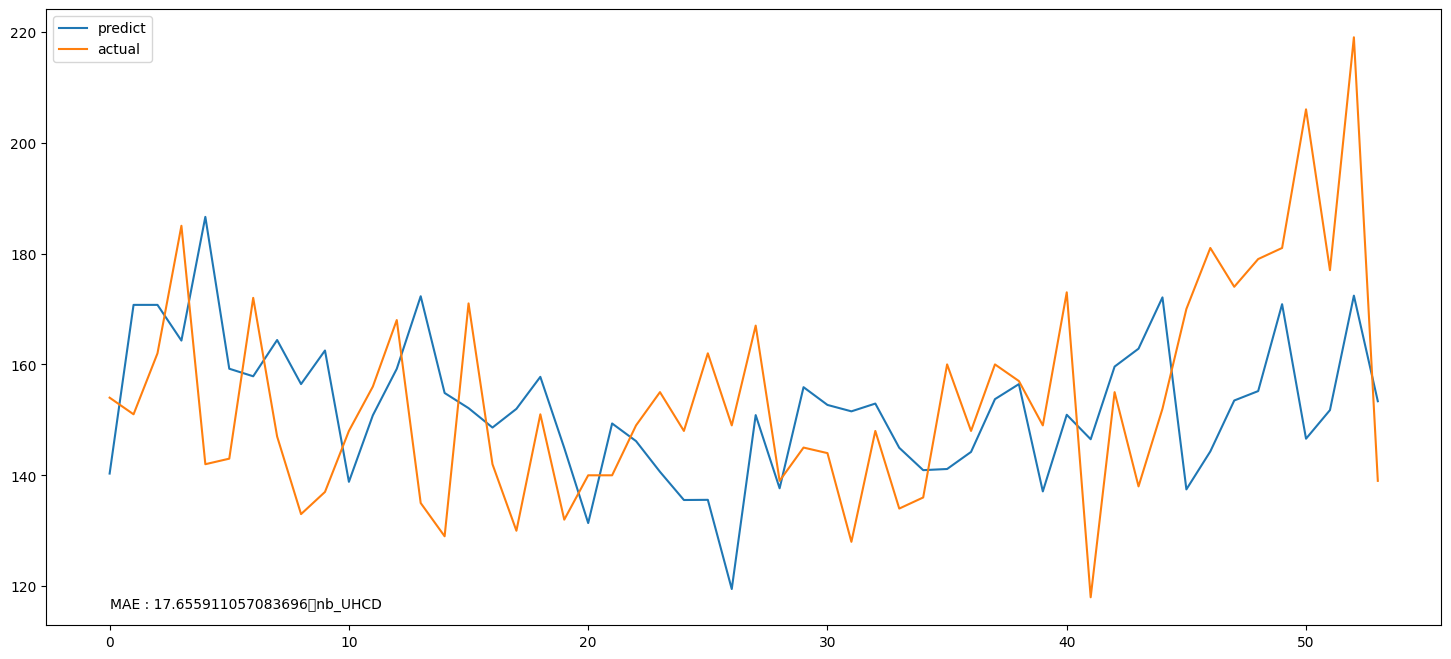

In [179]:
mes_cols = []
score = 1000
#print(dg)
for index, col in enumerate(liste):
    print(f"{index+1}/{len(liste)}: {col}")
    res = teste(dg[list(set(mes_cols+[col, 'target']))], params)
    #print(res)
    if res[1] < score:
        print(f" -> amélioration: {score:.4f} -> {res[1]:.4f}")
        score = res[1]
        mes_cols.append(col)
    #print(mes_cols)
    if index % 5 == 0:
        global_year = {'predict': [], 'actual': []}
        for month in range(1, 12, 2):
            start = dt.datetime(2023,month,1)
            stop = start + dt.timedelta(days=60)
            #print(dg[mes_cols+['target']])
            teste_final(dg[mes_cols+['target']], params, start, stop, plot=False)
plt.figure()
plt.plot(range(len(global_year['predict'])), global_year['predict'], label='predict')
plt.plot(range(len(global_year['actual'])), global_year['actual'], label='actual')
plt.text(0, min(global_year['actual'])-2, f"MAE : {mean_absolute_error(global_year['predict'], global_year['actual'])}" + "\t" + utils.TARGETS[target_index])
plt.legend()
plt.show()